In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import poisson

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("C:/Users/Joan/Desktop/TFG/db/SP1.csv")

In [ ]:
print(df.shape)

df.head()

(380, 119)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,BFH,BFD,BFA,PSH,PSD,PSA,WHH,WHD,WHA,1XBH,1XBD,1XBA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,BFEH,BFED,BFEA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,BFE>2.5,BFE<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,BFEAHH,BFEAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,BFCH,BFCD,BFCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,1XBCH,1XBCD,1XBCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,BFECH,BFECD,BFECA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,SP1,15/08/2024,18:00,Ath Bilbao,Getafe,1,1,D,1,0,H,7,9,4,2,15,12,5,6,4,1,0,0,1.48,4.00,8.00,1.44,4.20,7.75,1.53,3.9,7.50,1.48,4.12,8.24,1.44,4.0,8.50,1.52,4.16,8.50,1.58,4.20,8.90,1.51,4.04,7.61,1.57,4.0,8.20,2.20,1.67,2.34,1.65,2.34,1.71,2.24,1.67,2.30,1.76,-1.00,1.84,2.06,1.86,2.05,2.01,2.12,1.90,1.96,2.06,1.92,1.57,3.6,7.0,1.60,3.6,6.5,1.57,3.50,7.00,1.61,3.71,7.18,1.60,3.50,7.0,1.61,3.65,7.40,1.63,3.82,7.50,1.59,3.63,6.96,1.63,3.75,8.0,2.63,1.50,2.61,1.54,2.66,1.59,2.51,1.54,2.68,1.58,-1.00,2.08,1.73,2.17,1.76,2.19,1.82,2.12,1.77,2.19,1.82
1,SP1,15/08/2024,20:30,Betis,Girona,1,1,D,1,0,H,19,13,4,2,11,7,4,4,2,0,0,0,2.35,3.40,3.00,2.40,3.25,2.95,2.40,3.4,3.00,2.41,3.42,3.07,2.40,3.3,3.00,2.46,3.47,3.12,2.46,3.47,3.12,2.40,3.38,3.02,2.48,3.5,3.20,1.97,1.93,1.94,1.94,1.98,1.99,1.93,1.90,2.02,1.96,-0.25,2.06,1.84,2.08,1.84,2.09,1.87,2.04,1.81,2.12,1.88,2.30,3.4,3.1,2.35,3.3,3.0,2.30,3.25,3.10,2.35,3.43,3.21,2.40,3.20,3.1,2.34,3.47,3.16,2.50,3.47,3.21,2.35,3.37,3.10,2.42,3.45,3.3,1.95,1.95,1.94,1.96,2.00,2.00,1.94,1.89,2.02,1.96,-0.25,2.01,1.89,2.03,1.89,2.10,1.94,2.01,1.85,2.08,1.90
2,SP1,16/08/2024,18:00,Celta,Alaves,2,1,H,0,1,A,6,10,4,2,8,23,3,3,3,2,0,0,2.00,3.20,4.10,2.05,3.30,3.80,2.00,3.3,4.10,2.05,3.37,4.12,2.00,3.3,4.00,2.09,3.41,4.11,2.09,3.41,4.20,2.03,3.32,4.02,2.10,3.4,4.20,2.20,1.67,2.31,1.68,2.34,1.71,2.25,1.67,2.38,1.71,-0.50,2.06,1.87,2.06,1.88,2.07,1.88,2.03,1.85,2.10,1.89,2.10,3.1,3.9,2.05,3.2,3.8,2.05,3.10,3.75,2.15,3.27,3.89,2.05,3.25,3.9,2.11,3.18,4.14,2.15,3.34,4.14,2.10,3.24,3.86,2.16,3.35,4.0,2.30,1.62,2.40,1.63,2.40,1.67,2.31,1.63,2.44,1.68,-0.25,1.82,2.11,1.83,2.10,1.84,2.12,1.79,2.08,1.85,2.14
3,SP1,16/08/2024,20:30,Las Palmas,Sevilla,2,2,D,1,1,D,13,16,5,5,12,13,6,3,0,0,0,0,2.80,3.25,2.63,2.85,3.20,2.55,2.80,3.1,2.63,2.87,3.23,2.71,2.88,3.1,2.62,2.92,3.31,2.70,2.92,3.31,2.75,2.83,3.21,2.65,2.96,3.3,2.78,2.20,1.67,2.22,1.73,2.25,1.75,2.18,1.71,2.28,1.76,0.00,2.03,1.90,2.02,1.90,2.04,1.91,2.01,1.88,2.06,1.93,2.55,3.3,2.8,2.65,3.1,2.8,2.55,3.00,2.70,2.65,3.25,2.93,2.70,3.10,2.8,2.71,3.37,2.74,2.78,3.37,2.95,2.66,3.19,2.83,2.72,3.30,3.0,2.10,1.73,2.17,1.76,2.20,1.79,2.14,1.73,2.22,1.81,0.00,1.86,2.07,1.87,2.07,1.89,2.11,1.86,2.03,1.90,2.09
4,SP1,17/08/2024,18:00,Osasuna,Leganes,1,1,D,0,1,A,16,10,5,4,14,12,6,4,3,2,0,0,1.85,3.30,4.50,1.82,3.40,4.60,1.90,3.4,4.60,1.89,3.47,4.57,1.85,3.4,4.60,1.92,3.57,4.67,1.93,3.57,4.70,1.88,3.44,4.48,1.93,3.5,4.90,2.30,1.62,2.37,1.63,2.45,1.68,2.34,1.62,2.52,1.64,-0.50,1.91,2.02,1.90,2.00,1.93,2.04,1.88,1.98,1.93,2.05,1.83,3.1,5.0,1.85,3.2,5.0,1.80,3.10,4.75,1.88,3.28,5.19,1.85,3.25,4.8,1.86,3.29,5.32,1.91,3.41,5.32,1.87,3.26,4.92,1.91,3.40,5.3,2.75,1.44,2.90,1.47,2.90,1.54,2.69,1.48,2.96,1.50,-0.50,1.88,2.05,1.88,2.04,1.91,2.06,1.87,2.00,1.94,2.05


In [ ]:
cols = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
    "AvgH",
    "AvgD",
    "AvgA"
]

df = df[cols].copy()

In [ ]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

In [ ]:
df["PH"] = 1 / df["AvgH"]
df["PD"] = 1 / df["AvgD"]
df["PA"] = 1 / df["AvgA"]

In [ ]:
df["Overround"] = df["PH"] + df["PD"] + df["PA"]

df["Margin"] = df["Overround"] - 1

In [ ]:
print(df["Margin"].describe())

count    380.000000
mean       0.047491
std        0.003463
min        0.038521
25%        0.044808
50%        0.047716
75%        0.050114
max        0.059866
Name: Margin, dtype: float64


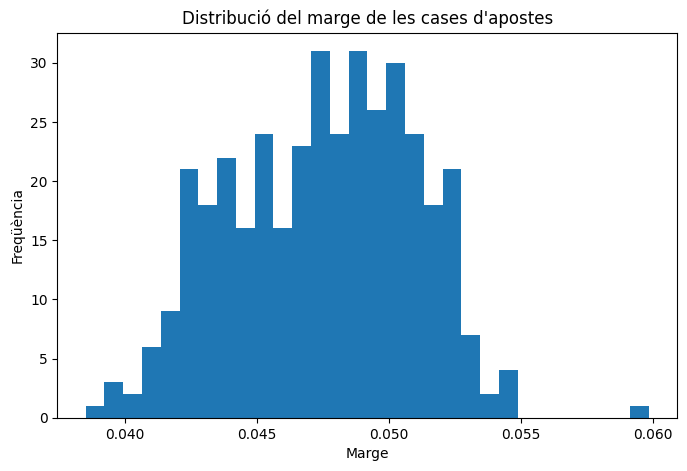

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Margin"], bins=30)

plt.xlabel("Marge")
plt.ylabel("Freqüència")
plt.title("Distribució del marge de les cases d'apostes")

plt.show()

In [ ]:
df["HomeWin"] = (df["FTR"] == "H").astype(int)
df["Draw"] = (df["FTR"] == "D").astype(int)
df["AwayWin"] = (df["FTR"] == "A").astype(int)

In [ ]:
bins = np.arange(0, 1.05, 0.05)

df["PH_bin"] = pd.cut(df["PH"], bins)

In [ ]:
calibration = df.groupby("PH_bin").agg(
    predicted=("PH", "mean"),
    actual=("HomeWin", "mean"),
    count=("HomeWin", "size")
)

print(calibration)

             predicted    actual  count
PH_bin                                 
(0.0, 0.05]        NaN       NaN      0
(0.05, 0.1]   0.086242  0.000000      3
(0.1, 0.15]   0.124462  0.250000      8
(0.15, 0.2]   0.178752  0.111111     18
(0.2, 0.25]   0.226792  0.173913     23
(0.25, 0.3]   0.274819  0.058824     17
(0.3, 0.35]   0.324686  0.355556     45
(0.35, 0.4]   0.374209  0.290323     31
(0.4, 0.45]   0.424319  0.434783     46
(0.45, 0.5]   0.476652  0.375000     32
(0.5, 0.55]   0.524513  0.500000     34
(0.55, 0.6]   0.577241  0.538462     39
(0.6, 0.65]   0.622264  0.631579     19
(0.65, 0.7]   0.675515  0.600000     10
(0.7, 0.75]   0.727167  0.809524     21
(0.75, 0.8]   0.775418  0.866667     15
(0.8, 0.85]   0.827349  1.000000     10
(0.85, 0.9]   0.871423  0.777778      9
(0.9, 0.95]        NaN       NaN      0
(0.95, 1.0]        NaN       NaN      0


C:\Users\Joan\AppData\Local\Temp\ipykernel_5572\2169304054.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby("PH_bin").agg(


In [ ]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df = df.sort_values("Date")

df.reset_index(
    drop=True,
    inplace=True
)

In [ ]:
def get_training_data(df, match_index):

    return df.iloc[:match_index].copy()

In [ ]:
def build_team_strengths(train_df):

    home_avg = train_df["FTHG"].mean()
    away_avg = train_df["FTAG"].mean()

    home_attack = (
        train_df.groupby("HomeTeam")["FTHG"].mean()
        / home_avg
    )

    home_defense = (
        train_df.groupby("HomeTeam")["FTAG"].mean()
        / away_avg
    )

    away_attack = (
        train_df.groupby("AwayTeam")["FTAG"].mean()
        / away_avg
    )

    away_defense = (
        train_df.groupby("AwayTeam")["FTHG"].mean()
        / home_avg
    )

    return (
        home_avg,
        away_avg,
        home_attack,
        home_defense,
        away_attack,
        away_defense
    )

In [ ]:
WINDOW_SIZE = 150

In [ ]:
def get_training_window(df, match_index):

    start = max(0, match_index - WINDOW_SIZE)

    return df.iloc[start:match_index].copy()

In [ ]:
train = get_training_window(df, 200)

print(len(train))

150


In [ ]:
def expected_goals_from_training(
    home_team,
    away_team,
    train_df
):

    (
        home_avg,
        away_avg,
        home_attack,
        home_defense,
        away_attack,
        away_defense
    ) = build_team_strengths(train_df)

    try:

        lambda_home = (
            home_attack[home_team]
            * away_defense[away_team]
            * home_avg
        )

        lambda_away = (
            away_attack[away_team]
            * home_defense[home_team]
            * away_avg
        )

        return lambda_home, lambda_away

    except KeyError:

        return None, None

In [ ]:
from scipy.stats import poisson

def score_matrix_training(
    home_team,
    away_team,
    train_df,
    max_goals=8
):

    lambda_home, lambda_away = expected_goals_from_training(
        home_team,
        away_team,
        train_df
    )

    if lambda_home is None:
        return None

    matrix = np.zeros(
        (max_goals + 1, max_goals + 1)
    )

    for i in range(max_goals + 1):
        for j in range(max_goals + 1):

            matrix[i, j] = (
                poisson.pmf(i, lambda_home)
                * poisson.pmf(j, lambda_away)
            )

    return matrix

In [ ]:
def outcome_probabilities_training(
    home_team,
    away_team,
    train_df
):

    matrix = score_matrix_training(
        home_team,
        away_team,
        train_df
    )

    if matrix is None:
        return None

    home_win = np.tril(matrix, -1).sum()
    draw = np.trace(matrix)
    away_win = np.triu(matrix, 1).sum()

    total = home_win + draw + away_win

    return (
        home_win / total,
        draw / total,
        away_win / total
    )

In [ ]:
train = get_training_window(df, 200)

outcome_probabilities_training(
    df.iloc[200]["HomeTeam"],
    df.iloc[200]["AwayTeam"],
    train
)

(np.float64(0.3779154776123989),
 np.float64(0.3881313197517091),
 np.float64(0.23395320263589195))

In [ ]:
predictions = []
indices = []

for idx in range(WINDOW_SIZE, len(df)):

    train_df = get_training_window(
        df,
        idx
    )

    home_team = df.iloc[idx]["HomeTeam"]
    away_team = df.iloc[idx]["AwayTeam"]

    probs = outcome_probabilities_training(
        home_team,
        away_team,
        train_df
    )

    if probs is None:
        continue

    predictions.append(probs)

    indices.append(idx)

In [ ]:
pred_df = pd.DataFrame(
    predictions,
    columns=["ModelH", "ModelD", "ModelA"]
)

pred_df["Index"] = indices

print(pred_df.shape)
pred_df.head()

(230, 4)


,ModelH,ModelD,ModelA,Index
0,0.228920,0.215456,0.555624,150
1,0.366190,0.328922,0.304888,151
2,0.695448,0.171212,0.133340,152
3,0.209126,0.205288,0.585586,153
4,0.095079,0.555905,0.349017,154


In [ ]:
eval_df = df.iloc[indices].copy()
eval_df.reset_index(drop=True, inplace=True)

pred_clean = pred_df[["ModelH", "ModelD", "ModelA"]].copy()
pred_clean.reset_index(drop=True, inplace=True)

eval_df = pd.concat([eval_df, pred_clean], axis=1)

print(eval_df.columns[eval_df.columns.duplicated()])

Index([], dtype='object')


In [ ]:
eval_df["RealH"] = (eval_df["FTR"] == "H").astype(int)
eval_df["RealD"] = (eval_df["FTR"] == "D").astype(int)
eval_df["RealA"] = (eval_df["FTR"] == "A").astype(int)

In [ ]:
model_brier = np.mean(

    (eval_df["ModelH"] - eval_df["RealH"])**2 +

    (eval_df["ModelD"] - eval_df["RealD"])**2 +

    (eval_df["ModelA"] - eval_df["RealA"])**2

)

print("Model Brier:", model_brier)

Model Brier: 0.6308583027093156


In [ ]:
eval_df["BookH"] = 1 / eval_df["AvgH"]
eval_df["BookD"] = 1 / eval_df["AvgD"]
eval_df["BookA"] = 1 / eval_df["AvgA"]

norm = eval_df["BookH"] + eval_df["BookD"] + eval_df["BookA"]

eval_df["BookH"] /= norm
eval_df["BookD"] /= norm
eval_df["BookA"] /= norm

book_brier = np.mean(
    (eval_df["BookH"] - eval_df["RealH"])**2 +
    (eval_df["BookD"] - eval_df["RealD"])**2 +
    (eval_df["BookA"] - eval_df["RealA"])**2
)

print("Bookmaker Brier:", book_brier)

Bookmaker Brier: 0.5655601245958466


El model Poisson basat únicament en les estadístiques recents dels equips és capaç de capturar part de la informació continguda en els resultats dels partits, però queda significativament per darrere de les probabilitats implícites del mercat.

In [ ]:
teams = sorted(
    set(df["HomeTeam"])
    .union(set(df["AwayTeam"]))
)

elo = {
    team: 1500
    for team in teams
}

In [ ]:
K= 20
def elo_expected(
    rating_a,
    rating_b
):

    return 1 / (
        1 +
        10 ** (
            (rating_b - rating_a) / 400
        )
    )

In [ ]:
def update_elo(
    rating_home,
    rating_away,
    result,
    K=20
):

    expected_home = elo_expected(
        rating_home,
        rating_away
    )

    expected_away = 1 - expected_home

    if result == "H":

        score_home = 1
        score_away = 0

    elif result == "D":

        score_home = 0.5
        score_away = 0.5

    else:

        score_home = 0
        score_away = 1

    rating_home += K * (
        score_home - expected_home
    )

    rating_away += K * (
        score_away - expected_away
    )

    return rating_home, rating_away

In [ ]:
elo_history = []

elo = {
    team: 1500
    for team in teams
}

In [ ]:
for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    elo_history.append(
        (
            elo[home],
            elo[away]
        )
    )

    new_home, new_away = update_elo(
        elo[home],
        elo[away],
        row["FTR"],
        K
    )

    elo[home] = new_home
    elo[away] = new_away

In [ ]:
df["HomeELO"] = [
    x[0]
    for x in elo_history
]

df["AwayELO"] = [
    x[1]
    for x in elo_history
]

In [ ]:
df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeELO",
        "AwayELO"
    ]
].head

<bound method NDFrame.head of        HomeTeam    AwayTeam      HomeELO      AwayELO
0    Ath Bilbao      Getafe  1500.000000  1500.000000
1         Betis      Girona  1500.000000  1500.000000
2         Celta      Alaves  1500.000000  1500.000000
3    Las Palmas     Sevilla  1500.000000  1500.000000
4       Osasuna     Leganes  1500.000000  1500.000000
..          ...         ...          ...          ...
375     Espanol  Las Palmas  1456.461397  1411.009924
376   Vallecano    Mallorca  1511.983880  1465.439531
377  Villarreal     Sevilla  1579.844803  1454.755865
378      Girona  Ath Madrid  1440.351013  1581.340849
379  Ath Bilbao   Barcelona  1592.312701  1634.004559

[380 rows x 4 columns]>

In [ ]:
def elo_factor(
    home_elo,
    away_elo
):

    return np.exp(
        (home_elo - away_elo)
        / 800
    )

In [ ]:
elo_factor(
    1700,
    1500
)

np.float64(1.2840254166877414)

In [ ]:
def expected_goals_with_elo(
    home_team,
    away_team,
    train_df,
    home_elo,
    away_elo
):

    (
        home_avg,
        away_avg,
        home_attack,
        home_defense,
        away_attack,
        away_defense
    ) = build_team_strengths(train_df)

    try:

        lambda_home = (
            home_attack[home_team]
            * away_defense[away_team]
            * home_avg
        )

        lambda_away = (
            away_attack[away_team]
            * home_defense[home_team]
            * away_avg
        )

        factor = elo_factor(
            home_elo,
            away_elo
        )

        lambda_home *= factor
        lambda_away /= factor

        return (
            lambda_home,
            lambda_away
        )

    except KeyError:

        return None, None

In [ ]:
df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeELO",
        "AwayELO"
    ]
].tail(20)

,HomeTeam,AwayTeam,HomeELO,AwayELO
360,Las Palmas,Leganes,1420.325595,1444.138866
361,Ath Madrid,Betis,1571.870266,1553.459212
362,Barcelona,Villarreal,1646.229280,1567.620082
363,Celta,Vallecano,1516.859886,1501.543320
364,Mallorca,Getafe,1476.222022,1448.979793
365,Osasuna,Espanol,1510.442629,1465.165545
366,Sevilla,Real Madrid,1460.599962,1614.288016
367,Sociedad,Girona,1458.717467,1450.103123
368,Valencia,Ath Bilbao,1506.306419,1584.526782
369,Valladolid,Alaves,1334.886135,1467.715601


In [ ]:
df["HomeELO"].describe()

count     380.000000
mean     1499.096091
std        45.799271
min      1334.886135
25%      1471.891182
50%      1495.874929
75%      1516.726860
max      1646.229280
Name: HomeELO, dtype: float64

In [ ]:
df["AwayELO"].describe()


count     380.000000
mean     1500.679868
std        45.048273
min      1328.533288
25%      1474.975793
50%      1497.064568
75%      1518.837896
max      1640.769161
Name: AwayELO, dtype: float64

In [ ]:
df["ELO_Diff"] = (
    df["HomeELO"]
    - df["AwayELO"]
)

In [ ]:
df.groupby("FTR")["ELO_Diff"].mean()

FTR
A   -34.765393
D    -2.914499
H    21.562877
Name: ELO_Diff, dtype: float64

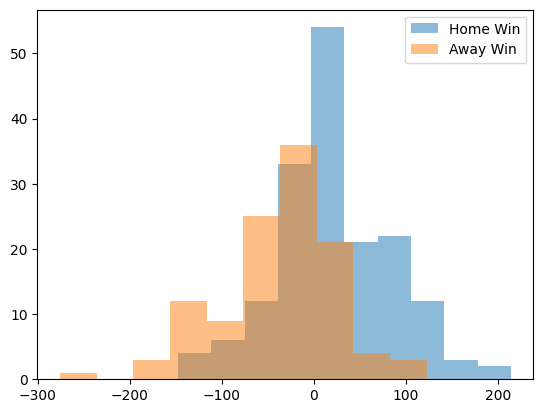

In [ ]:
plt.hist(
    df[df["FTR"]=="H"]["ELO_Diff"],
    alpha=0.5,
    label="Home Win"
)

plt.hist(
    df[df["FTR"]=="A"]["ELO_Diff"],
    alpha=0.5,
    label="Away Win"
)

plt.legend()
plt.show()

In [ ]:
draw_rate = (df["FTR"] == "D").mean()
print(draw_rate)

0.25526315789473686


In [ ]:
elo_home_win = []

elo_draw = []

elo_away_win = []

In [ ]:
for _, row in df.iterrows():

    p_home_raw = elo_expected(
        row["HomeELO"],
        row["AwayELO"]
    )

    p_home = p_home_raw * (1 - draw_rate)

    p_away = (1 - p_home_raw) * (1 - draw_rate)

    p_draw = draw_rate

    elo_home_win.append(p_home)

    elo_draw.append(p_draw)

    elo_away_win.append(p_away)

In [ ]:
df["ELO_H"] = elo_home_win
df["ELO_D"] = elo_draw
df["ELO_A"] = elo_away_win

In [ ]:
elo_brier = np.mean(

    (df["ELO_H"] - (df["FTR"]=="H").astype(int))**2 +

    (df["ELO_D"] - (df["FTR"]=="D").astype(int))**2 +

    (df["ELO_A"] - (df["FTR"]=="A").astype(int))**2

)

print("ELO Brier:", elo_brier)

ELO Brier: 0.6248870000792347


In [ ]:
def elo_adjustment(
    home_elo,
    away_elo
):

    return 1 + (
        (home_elo - away_elo)
        / 1000
    )

In [ ]:
def expected_goals_hybrid(
    home_team,
    away_team,
    train_df,
    home_elo,
    away_elo
):

    (
        home_avg,
        away_avg,
        home_attack,
        home_defense,
        away_attack,
        away_defense
    ) = build_team_strengths(
        train_df
    )

    try:

        home_att = home_attack[home_team]
        away_att = away_attack[away_team]

        factor = elo_adjustment(
            home_elo,
            away_elo
        )

        home_att *= factor
        away_att /= factor

        lambda_home = (
            home_att
            * away_defense[away_team]
            * home_avg
        )

        lambda_away = (
            away_att
            * home_defense[home_team]
            * away_avg
        )

        return (
            lambda_home,
            lambda_away
        )

    except KeyError:

        return None, None

In [ ]:
def score_matrix_hybrid(
    home_team,
    away_team,
    train_df,
    home_elo,
    away_elo,
    max_goals=8
):

    lambda_home, lambda_away = (
        expected_goals_hybrid(
            home_team,
            away_team,
            train_df,
            home_elo,
            away_elo
        )
    )

    if lambda_home is None:
        return None

    matrix = np.zeros(
        (max_goals+1, max_goals+1)
    )

    for i in range(max_goals+1):
        for j in range(max_goals+1):

            matrix[i,j] = (

                poisson.pmf(
                    i,
                    lambda_home
                )

                *

                poisson.pmf(
                    j,
                    lambda_away
                )

            )

    return matrix

In [ ]:
def hybrid_probabilities(
    home_team,
    away_team,
    train_df,
    home_elo,
    away_elo
):

    matrix = score_matrix_hybrid(
        home_team,
        away_team,
        train_df,
        home_elo,
        away_elo
    )

    if matrix is None:
        return None

    home_win = np.tril(
        matrix,
        -1
    ).sum()

    draw = np.trace(
        matrix
    )

    away_win = np.triu(
        matrix,
        1
    ).sum()

    total = (
        home_win
        + draw
        + away_win
    )

    return (
        home_win / total,
        draw / total,
        away_win / total
    )

In [ ]:
hybrid_predictions = []

hybrid_indices = []

for idx in range(
    WINDOW_SIZE,
    len(df)
):

    train_df = get_training_window(
        df,
        idx
    )

    row = df.iloc[idx]

    probs = hybrid_probabilities(

        row["HomeTeam"],
        row["AwayTeam"],

        train_df,

        row["HomeELO"],
        row["AwayELO"]

    )

    if probs is None:
        continue

    hybrid_predictions.append(
        probs
    )

    hybrid_indices.append(
        idx
    )

In [ ]:
hybrid_df = pd.DataFrame(

    hybrid_predictions,

    columns=[
        "HybridH",
        "HybridD",
        "HybridA"
    ]

)

hybrid_df["Index"] = (
    hybrid_indices
)

In [ ]:
hybrid_df.shape
hybrid_df.head()

,HybridH,HybridD,HybridA,Index
0,0.197679,0.204282,0.598038,150
1,0.356908,0.329501,0.313591,151
2,0.720918,0.160876,0.118205,152
3,0.172986,0.190051,0.636962,153
4,0.090510,0.549227,0.360263,154


In [ ]:
hybrid_eval = df.iloc[hybrid_indices].copy()

hybrid_eval.reset_index(
    drop=True,
    inplace=True
)

hybrid_df.reset_index(
    drop=True,
    inplace=True
)

hybrid_eval = pd.concat(
    [
        hybrid_eval,
        hybrid_df[
            [
                "HybridH",
                "HybridD",
                "HybridA"
            ]
        ]
    ],
    axis=1
)

In [ ]:
hybrid_eval["RealH"] = (
    hybrid_eval["FTR"] == "H"
).astype(int)

hybrid_eval["RealD"] = (
    hybrid_eval["FTR"] == "D"
).astype(int)

hybrid_eval["RealA"] = (
    hybrid_eval["FTR"] == "A"
).astype(int)

In [ ]:
hybrid_brier = np.mean(

    (hybrid_eval["HybridH"]
     - hybrid_eval["RealH"])**2

    +

    (hybrid_eval["HybridD"]
     - hybrid_eval["RealD"])**2

    +

    (hybrid_eval["HybridA"]
     - hybrid_eval["RealA"])**2

)

print(
    "Hybrid Brier:",
    hybrid_brier
)

Hybrid Brier: 0.6286908964771978
